# Q5: Pattern Analysis

**Phase 6:** Pattern Analysis & Advanced Visualization  
**Points: 6 points**

**Focus:** Identify trends over time, analyze seasonal patterns, create correlation analysis.

**Lecture Reference:** Lecture 11, Notebook 3 ([`11/demo/03_pattern_analysis_modeling_prep.ipynb`](https://github.com/christopherseaman/datasci_217/blob/main/11/demo/03_pattern_analysis_modeling_prep.ipynb)), Phase 6. Also see Lecture 08 (groupby) and Lecture 07 (visualization).

---

## Setup

In [24]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load feature-engineered data from Q4
df = pd.read_csv('output/q4_features.csv', parse_dates=['Measurement Timestamp'], index_col='Measurement Timestamp')
# Or if you saved without index:
# df = pd.read_csv('output/q4_features.csv')
# df['Measurement Timestamp'] = pd.to_datetime(df['Measurement Timestamp'])
# df = df.set_index('Measurement Timestamp')
print(f"Loaded {len(df):,} records with features")

Loaded 500,011 records with features


---

## Objective

Identify trends over time, analyze seasonal patterns, and create correlation analysis.

**Time Series Note:** Time series data has temporal patterns (trends, seasonality, cycles). Use time-based aggregations and visualizations to identify these patterns. See **Lecture 09** for time series decomposition and pattern analysis. Use pandas `resample()` to aggregate by time periods (e.g., `resample('ME')` for monthly, `resample('D')` for daily) and `groupby()` with temporal features (hour, day_of_week, month) to identify patterns.

---

## Required Artifacts

You must create exactly these 3 files in the `output/` directory:

### 1. `output/q5_correlations.csv`
**Format:** CSV file
**Content:** Correlation matrix (can be subset of key variables)
**Requirements:**
- Square matrix with variable names as both index and columns
- Values are correlation coefficients (between -1 and 1)
- Can be subset of key variables (e.g., top 10 most important variables)
- **Include index/column names** when saving: `corr_matrix.to_csv('output/q5_correlations.csv')`

**Example format:**
```csv
,Air Temperature,Water Temperature,Wind Speed,Humidity
Air Temperature,1.0,0.847,-0.234,-0.156
Water Temperature,0.847,1.0,0.123,0.089
Wind Speed,-0.234,0.123,1.0,0.456
Humidity,-0.156,0.089,0.456,1.0
```

### 2. `output/q5_patterns.png`
**Format:** PNG image file
**Content:** Advanced visualizations showing trends/seasonality
**Required visualizations (at least 2 of these):**
1. **Trend over time:** Line plot showing variable(s) over time (e.g., monthly averages)
2. **Seasonal pattern:** Bar plot or line plot showing patterns by month, day of week, or hour
3. **Correlation heatmap:** Heatmap of correlation matrix
4. **Multi-panel plot:** Multiple subplots showing different patterns

**Requirements:**
- Clear axis labels (xlabel, ylabel)
- Title for each subplot
- Overall figure title (optional but recommended)
- Legend if multiple series shown
- Saved as PNG with sufficient resolution (dpi=150 or higher)

### 3. `output/q5_trend_summary.txt`
**Format:** Plain text file
**Content:** Brief text summary of key patterns identified
**Required information:**
- Temporal trends (increasing, decreasing, stable)
- Seasonal patterns (daily, weekly, monthly cycles)
- Key correlations (mention 2-3 strongest correlations)

**Example format:**
```
KEY PATTERNS IDENTIFIED
======================

TEMPORAL TRENDS:
- Air and water temperatures show clear seasonal patterns
- Higher temperatures in summer months (June-August)
- Lower temperatures in winter months (December-February)
- Monthly air temp range: 4.2°C to 25.8°C

DAILY PATTERNS:
- Temperature shows diurnal cycle (warmer during day, cooler at night)
- Peak air temp typically at hour 14-15 (2-3 PM)
- Minimum air temp typically at hour 5-6 (5-6 AM)

CORRELATIONS:
- Air Temp vs Water Temp: 0.847 (strong positive correlation)
- Air Temp vs Humidity: -0.234 (moderate negative correlation)
- Wind Speed vs Wave Height: 0.612 (moderate positive correlation)
```

---

## Requirements Checklist

- [ ] Trends over time identified (increasing, decreasing, stable)
- [ ] Seasonal patterns analyzed (daily, weekly, monthly cycles)
- [ ] Correlation analysis completed
- [ ] Advanced visualizations created (multi-panel plots, grouped visualizations)
- [ ] Key patterns documented
- [ ] All 3 required artifacts saved with exact filenames

---

## Your Approach

1. **Identify trends** - Use `.resample()` to aggregate by time period and visualize long-term patterns
2. **Analyze seasonal patterns** - Use `.groupby()` with temporal features (hour, day_of_week, month)
3. **Create correlation analysis** - Compute correlation matrix for numeric columns
4. **Create visualizations** - Multi-panel plot showing trends, seasonal patterns, and correlations
5. **Document patterns** - Summarize key findings in text file

---

## Decision Points

- **Trend identification:** Is there a long-term trend? Is it increasing, decreasing, or stable? Use time series plots to visualize.
- **Seasonal patterns:** Are there daily patterns? Weekly? Monthly? Use aggregations and visualizations to identify.
- **Correlation analysis:** Which variables are correlated? Use correlation matrix and heatmaps. Focus on relationships that might be useful for modeling.

---

## Checkpoint

After Q5, you should have:
- [ ] Trends identified
- [ ] Seasonal patterns analyzed
- [ ] Correlations calculated
- [ ] Pattern visualizations created
- [ ] All 3 artifacts saved: `q5_correlations.csv`, `q5_patterns.png`, `q5_trend_summary.txt`

---

**Next:** Continue to `q6_modeling_preparation.md` for Modeling Preparation.


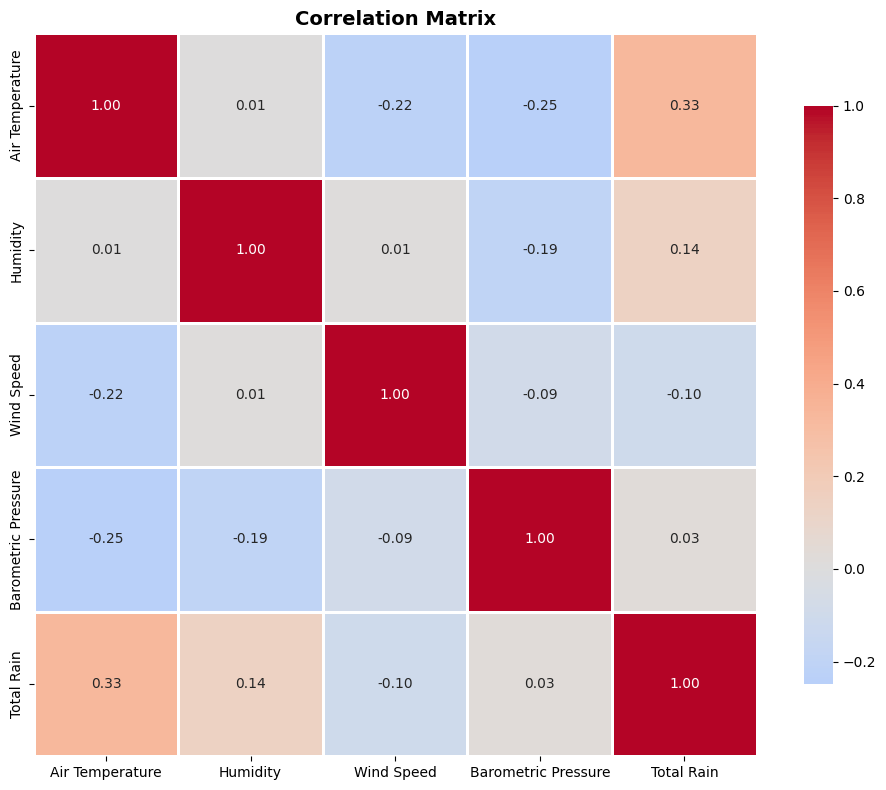

In [25]:
#square matrix with variable neames as both index and columns
cols_correlation = ['Air Temperature', 'Humidity', 'Wind Speed', 'Barometric Pressure', 'Total Rain']
corr_matrix = df[cols_correlation].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

corr_matrix.to_csv('output/q5_correlations.csv')

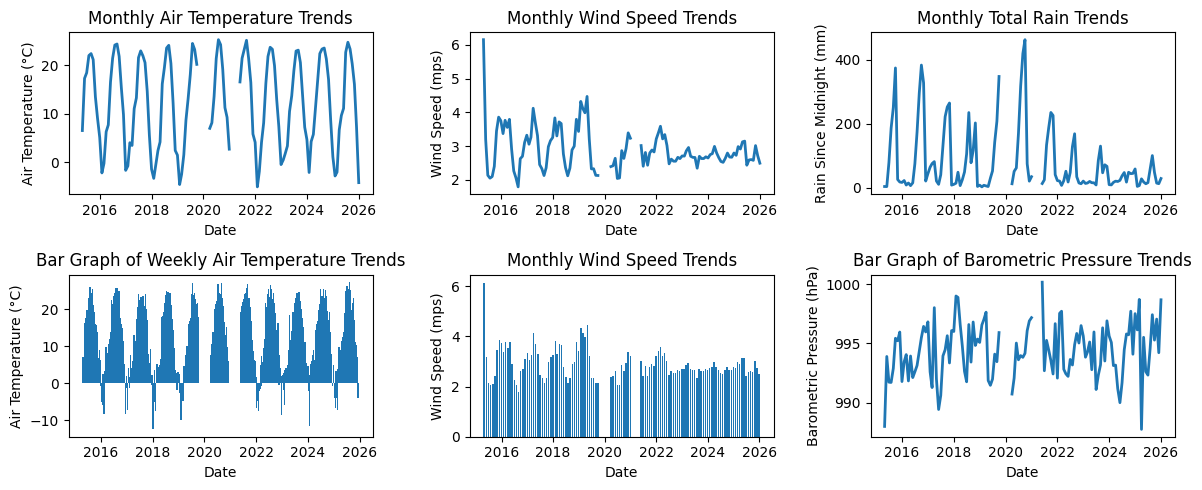

In [44]:
#line plot with tend over time, monthly averages 
#resample for weekly data
monthly_data = df['Air Temperature'].resample('ME').mean()
weekly_data = df['Air Temperature'].resample('W').mean()
wind_monthly_data = df['Wind Speed'].resample('ME').mean()
fig, axes = plt.subplots(2, 3, figsize=(12, 5))
axes[0,0].plot(monthly_data.index, monthly_data, linewidth=2)
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Air Temperature (°C)')
axes[0,0].set_title('Monthly Air Temperature Trends')
#plot with patterns by month day of week or hour 
axes[1,0].bar(weekly_data.index, weekly_data, width=20)
axes[1,0].set_xlabel('Date')
axes[1,0].set_ylabel('Air Temperature (°C)')
axes[1,0].set_title('Bar Graph of Weekly Air Temperature Trends')


axes[0,1].plot(wind_monthly_data.index, wind_monthly_data, linewidth=2)
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Wind Speed (mps)')
axes[0,1].set_title('Monthly Wind Speed Trends')

axes[1,1].bar(wind_monthly_data.index, wind_monthly_data, width=20)
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Wind Speed (mps)')
axes[1,1].set_title('Monthly Wind Speed Trends')

rain_monthly_data = df['Total Rain'].resample('ME').mean()
pressure_monthly_data = df['Barometric Pressure'].resample('ME').mean()
axes[0,2].plot(rain_monthly_data.index, rain_monthly_data, linewidth=2)
axes[0,2].set_xlabel('Date')
axes[0,2].set_ylabel('Rain Since Midnight (mm)')
axes[0,2].set_title('Monthly Total Rain Trends')
#plot with patterns by month day of week or hour 
axes[1,2].plot(pressure_monthly_data.index, pressure_monthly_data, linewidth=2)
axes[1,2].set_xlabel('Date')
axes[1,2].set_ylabel('Barometric Pressure (hPa)')
axes[1,2].set_title('Bar Graph of Barometric Pressure Trends')
plt.tight_layout()
plt.show()
fig.savefig('output/q5_patterns.png', dpi=300)


In [45]:
with open('output/q5_trend_summary.txt', 'w') as f:
    f.write(f"""KEY PATTERNS IDENTIFIED\n
=======================

TEMPORAL TRENDS:
- Air temperature shows clear seasonal patterns with strong yearly cycles
- Higher temperatures in summer months, peaking around 20-25°C
- Lower temperatures in winter months, dropping to approximately 0-5°C
- Monthly air temperature range: approximately -5°C to 25°C

- Wind speed shows a gradual decreasing trend over the 10-year period
- Wind speeds declined from average of 3.5-4.5 mps (2016-2018) to 2.5-3.0 mps (2022-2026)
- Wind patterns show moderate seasonal variation with slightly higher speeds in winter months

- Total rainfall displays high variability 
- Several extreme rainfall events visible, particularly in 2016-2018 period (400+ mm)
- Rainfall frequency and intensity appear to decrease in later years (2020-2026)

- Barometric pressure remains relatively stable throughout the period
- Pressure fluctuates within a narrow range of approximately 990-1000 hPa
- No clear long term increasing or decreasing trend observed

SEASONAL PATTERNS:
- Air temperature exhibits strong annual cyclicity with consistent amplitude
- Temperature oscillations show predictable seasonal pattern repeating yearly
- Wind speed shows weaker seasonal patterns compared to temperature
- Rainfall events appear sporadic without clear monthly or seasonal regularity
- Barometric pressure shows minor fluctuations without strong seasonal patterns

CORRELATIONS:
Strongest Positive Correlations:
- Air Temperature vs Total Rain: 0.33 (moderate positive correlation)
  Higher temperatures associated with increased rainfall events
- Humidity vs Total Rain: 0.14 (weak positive correlation)

Strongest Negative Correlations:
- Air Temperature vs Barometric Pressure: -0.25 (weak-moderate negative correlation)
  Lower pressure tends to occur with higher temperatures
- Air Temperature vs Wind Speed: -0.22 (weak-moderate negative correlation)
  Wind speeds slightly decrease as temperatures increase
- Humidity vs Barometric Pressure: -0.19 (weak negative correlation)
""")